In [1]:
import argparse
import os
from pathlib import Path
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Configuration

Choose which digit (0-9) to treat as the normal baseline class. All other digits will be treated as anomalies.

In [2]:
# Configuration
BASELINE_DIGIT = 0 # Change this to any digit 0-9
DATA_ROOT = './data'
FILTERED_OUT_DIR = './score_demo/filtered'
SAVE_FILTERED = True

Path(FILTERED_OUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Baseline digit: {BASELINE_DIGIT}")
print(f"Output directory: {FILTERED_OUT_DIR}")

Baseline digit: 0
Output directory: ./score_demo/filtered


## Helper Functions

In [3]:
def save_mnist_digit_as_pt(root, digit, out_path, train=True, download=True):
    """
    Saves MNIST samples of a single digit to a .pt file with keys:
      - 'data': float32 tensor, shape [N, 1, 28, 28] in [0,1]
      - 'targets': int64 tensor, shape [N]
    """
    ds = datasets.MNIST(root=root, train=train, download=download, transform=None)

    # ds.targets and ds.data are torch tensors in modern torchvision
    targets = ds.targets
    data = ds.data  # uint8 [N,28,28]

    idxs = (targets == digit).nonzero(as_tuple=True)[0]
    filtered_data = data[idxs].unsqueeze(1).float().div(255.0)   # [N,1,28,28]
    filtered_targets = targets[idxs].long()

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save({"data": filtered_data, "targets": filtered_targets}, out_path)
    print(f"Saved: {out_path}")
    print(f"  data: {filtered_data.shape}, dtype={filtered_data.dtype}, min={filtered_data.min().item():.3f}, max={filtered_data.max().item():.3f}")
    print(f"  targets unique: {filtered_targets.unique().tolist()}  count={filtered_targets.numel()}")

## Load and Filter Training Data

In [4]:
print(f"Loading MNIST training set and filtering for digit {BASELINE_DIGIT}...")
# Load filtered data directly
ds = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=None)
targets = ds.targets
data = ds.data

idxs = (targets == BASELINE_DIGIT).nonzero(as_tuple=True)[0]
train_data_filtered = data[idxs]  # Keep as PIL-compatible for visualization
train_count = len(idxs)
print(f"Filtered train size (digit {BASELINE_DIGIT} only): {train_count}")

Loading MNIST training set and filtering for digit 0...
Filtered train size (digit 0 only): 5923


## Save Filtered Training Set (Optional)

In [5]:
if SAVE_FILTERED:
    out_path = Path(FILTERED_OUT_DIR) / f'mnist_train_digit_{BASELINE_DIGIT}.pt'
    save_mnist_digit_as_pt(DATA_ROOT, BASELINE_DIGIT, out_path, train=True)

Saved: score_demo/filtered/mnist_train_digit_0.pt
  data: torch.Size([5923, 1, 28, 28]), dtype=torch.float32, min=0.000, max=1.000
  targets unique: [0]  count=5923


## Load Full Test Set

In [6]:
print(f"Loading full MNIST test set (all digits 0-9)...")
# Load without transform to avoid PIL issues
test_ds = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=None)
print(f"Test set size: {len(test_ds)}")

# Show distribution of test labels
if hasattr(test_ds.targets, 'numpy'):
    test_labels = test_ds.targets.numpy()
else:
    test_labels = np.array(test_ds.targets)
unique, counts = np.unique(test_labels, return_counts=True)
print("\nTest set label distribution:")
for digit, count in zip(unique, counts):
    label_type = "(NORMAL)" if digit == BASELINE_DIGIT else "(ANOMALY)"
    print(f"  Digit {digit}: {count} samples {label_type}")

Loading full MNIST test set (all digits 0-9)...
Test set size: 10000

Test set label distribution:
  Digit 0: 980 samples (NORMAL)
  Digit 1: 1135 samples (ANOMALY)
  Digit 2: 1032 samples (ANOMALY)
  Digit 3: 1010 samples (ANOMALY)
  Digit 4: 982 samples (ANOMALY)
  Digit 5: 892 samples (ANOMALY)
  Digit 6: 958 samples (ANOMALY)
  Digit 7: 1028 samples (ANOMALY)
  Digit 8: 974 samples (ANOMALY)
  Digit 9: 1009 samples (ANOMALY)


## Visualize Sample Images from Filtered Training Set

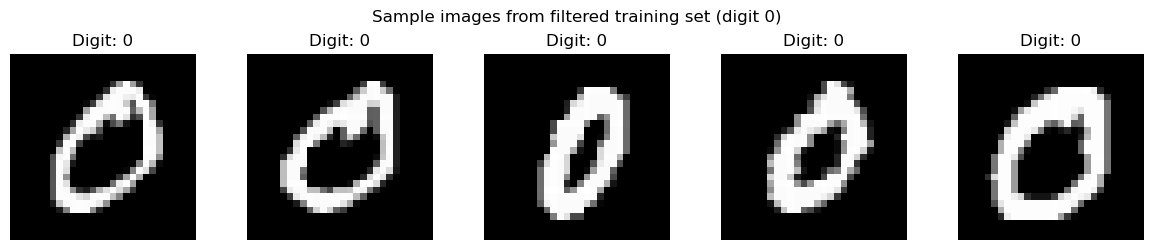

In [7]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(12, 2.5))

n_show = min(5, len(train_data_filtered))
for i in range(n_show):
    img = train_data_filtered[i]

    # Handle possible shapes:
    # - [28, 28]
    # - [1, 28, 28]
    # - [28, 28, 1]
    if torch.is_tensor(img):
        img = img.detach().cpu()
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]          # [1,28,28] -> [28,28]
        elif img.ndim == 3 and img.shape[-1] == 1:
            img = img[..., 0]     # [28,28,1] -> [28,28]
        img = img.numpy()

    # Ensure numeric type matplotlib likes
    img = np.asarray(img)
    if img.dtype != np.uint8 and img.dtype != np.float32 and img.dtype != np.float64:
        img = img.astype(np.float32)

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Digit: {BASELINE_DIGIT}")
    axes[i].axis("off")

plt.suptitle(f"Sample images from filtered training set (digit {BASELINE_DIGIT})")
plt.tight_layout()
plt.show()


## Next Steps: Evaluate on Test Set

After training, you can evaluate the model on the test set to compute anomaly scores and assess performance.

## Training a Score Network

Now we'll train a neural network to learn the score function for the baseline digit.


In [8]:
# Training configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Noise levels for training
SIGMA_MIN = 0.01
SIGMA_MAX = 0.3

# Training hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 5
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
LOG_EVERY = 50

# Model checkpoint path
MODEL_CHECKPOINT_DIR = Path('./score_demo/checkpoints')
MODEL_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_CHECKPOINT_PATH = MODEL_CHECKPOINT_DIR / f'model_digit_{BASELINE_DIGIT}.pt'

print(f"Training config:")
print(f"  Sigma range: [{SIGMA_MIN}, {SIGMA_MAX}]")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Model will be saved to: {MODEL_CHECKPOINT_PATH}")

Using device: cpu
Training config:
  Sigma range: [0.01, 0.3]
  Batch size: 64
  Epochs: 5
  Learning rate: 0.0002
  Model will be saved to: score_demo/checkpoints/model_digit_0.pt


### Model Architecture

In [9]:
class ScoreNet(torch.nn.Module):
    """
    Neural network that learns the score function.
    
    Input:
      x_tilde: [B, 1, 28, 28] noisy image
      sigma:   [B] noise level
    Output:
      score:   [B, 1, 28, 28] predicted score field
    """
    def __init__(self, base_channels=64):
        super().__init__()
        c = base_channels
        
        # 2 input channels: image + log_sigma channel
        self.conv1 = torch.nn.Conv2d(2, c, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(c, c, kernel_size=3, padding=1)
        self.conv3 = torch.nn.Conv2d(c, c, kernel_size=3, padding=1)
        self.conv4 = torch.nn.Conv2d(c, 1, kernel_size=3, padding=1)
        
        self.gn1 = torch.nn.GroupNorm(8, c)
        self.gn2 = torch.nn.GroupNorm(8, c)
        self.gn3 = torch.nn.GroupNorm(8, c)
    
    def forward(self, x_tilde, sigma):
        # sigma is [B], convert to [B,1,1,1]
        sigma_broadcast = sigma.view(-1, 1, 1, 1)
        log_sigma = torch.log(sigma_broadcast + 1e-12)
        
        # expand to an image-sized channel
        sigma_channel = log_sigma.expand(-1, 1, x_tilde.shape[2], x_tilde.shape[3])
        h = torch.cat([x_tilde, sigma_channel], dim=1)
        
        h = torch.nn.functional.silu(self.gn1(self.conv1(h)))
        h = torch.nn.functional.silu(self.gn2(self.conv2(h)))
        h = torch.nn.functional.silu(self.gn3(self.conv3(h)))
        out = self.conv4(h)
        return out


def sample_sigma(batch_size, device, sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX):
    """
    Sample noise levels from a log-uniform distribution.
    
    Args:
        batch_size: Number of samples to draw
        device: torch device
        sigma_min: Minimum noise level
        sigma_max: Maximum noise level
    
    Returns:
        sigma: Tensor of shape [batch_size] with sampled noise levels
    """
    log_sigma_min = torch.log(torch.tensor(sigma_min, device=device))
    log_sigma_max = torch.log(torch.tensor(sigma_max, device=device))
    
    # Uniform sampling in log-space
    log_sigma = torch.rand(batch_size, device=device) * (log_sigma_max - log_sigma_min) + log_sigma_min
    
    # Convert back to sigma
    sigma = torch.exp(log_sigma)
    return sigma


def dsm_loss(model, images, sigma, x_tilde):
    """
    Denoising Score Matching (DSM) loss.
    
    The model learns to predict: (images - x_tilde) / sigma^2
    which is the true score of the Gaussian noise.
    
    Args:
        model: ScoreNet model
        images: Clean images [B,1,28,28]
        sigma: Noise levels [B]
        x_tilde: Noisy images [B,1,28,28]
    
    Returns:
        loss: Scalar loss value
    """
    sigma_broadcast = sigma.view(-1, 1, 1, 1)
    
    target = (images - x_tilde) / (sigma_broadcast ** 2 + 1e-12)  # [B,1,28,28]
    pred = model(x_tilde, sigma)  # [B,1,28,28]
    
    # Optional weighting to balance scales
    weight = sigma_broadcast ** 2
    loss = (weight * (pred - target) ** 2).mean()
    return loss

### Create Data Loader

In [10]:
# Create data loader for filtered training set
# Load the filtered data and convert to tensor form for the dataloader
filtered_data_tensor = train_data_filtered.unsqueeze(1).float() / 255.0  # [N, 1, 28, 28]
train_dataset = torch.utils.data.TensorDataset(filtered_data_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Created training dataloader:")
print(f"  Samples: {len(train_dataset)}")
print(f"  Batches per epoch: {len(train_loader)}")
print(f"  Batch size: {BATCH_SIZE}")

Created training dataloader:
  Samples: 5923
  Batches per epoch: 93
  Batch size: 64


### Initialize Model and Optimizer

In [11]:
model = ScoreNet(base_channels=64).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

use_amp = (DEVICE.type == "cuda")
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print(f"Model initialized on {DEVICE}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model initialized on cpu
Total parameters: 76,033


/var/folders/91/j3k25b391lv5t2z7dsh5s1b00000gn/T/ipykernel_27005/2940512776.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


### Training Loop

In [12]:
def train_one_epoch(model, train_loader, optimizer, scaler, epoch, device, log_every=50):
    """Train the model for one epoch."""
    model.train()
    running_loss = 0.0
    
    for step, (images_batch,) in enumerate(train_loader):
        images = images_batch.to(device)  # [B, 1, 28, 28]
        batch_size = images.shape[0]
        
        # Sample sigma for this batch
        sigma = sample_sigma(batch_size, device)
        
        # Corrupt images
        epsilon = torch.randn_like(images)
        sigma_broadcast = sigma.view(-1, 1, 1, 1)
        x_tilde = images + sigma_broadcast * epsilon
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.cuda.amp.autocast(enabled=use_amp):
            loss = dsm_loss(model, images, sigma, x_tilde)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        if (step + 1) % log_every == 0:
            avg_loss = running_loss / log_every
            print(f"Epoch {epoch} Step {step+1}/{len(train_loader)} Loss={avg_loss:.6f}")
            running_loss = 0.0


# Train the model
print(f"\n{'='*60}")
print(f"Starting training for digit {BASELINE_DIGIT}")
print(f"{'='*60}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    train_one_epoch(model, train_loader, optimizer, scaler, epoch, DEVICE, log_every=LOG_EVERY)

# Save the model
torch.save(model.state_dict(), MODEL_CHECKPOINT_PATH)
print(f"\n{'='*60}")
print(f"Training complete! Model saved to: {MODEL_CHECKPOINT_PATH}")
print(f"{'='*60}")


Starting training for digit 0



/var/folders/91/j3k25b391lv5t2z7dsh5s1b00000gn/T/ipykernel_27005/2291563539.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1 Step 50/93 Loss=0.877887
Epoch 2 Step 50/93 Loss=0.679606
Epoch 3 Step 50/93 Loss=0.637600
Epoch 4 Step 50/93 Loss=0.594240
Epoch 5 Step 50/93 Loss=0.568830

Training complete! Model saved to: score_demo/checkpoints/model_digit_0.pt


In [ ]:
print(f"\n=== Summary ===")
print(f"Baseline digit: {BASELINE_DIGIT}")
print(f"Training set size (digit {BASELINE_DIGIT} only): {train_count}")
print(f"Full test set size: {len(test_ds)}")
print(f"Normal samples in test: {np.sum(test_labels == BASELINE_DIGIT)}")
print(f"Anomaly samples in test: {np.sum(test_labels != BASELINE_DIGIT)}")


=== Summary ===
Baseline digit: 9
Training set size (digit 9 only): 5949
Full test set size: 10000


AttributeError: module 'numpy.core.multiarray' has no attribute 'integer'